<div align="center">

Assignment 5 Part 2: Transfer Learning for Sentiment Analysis

AML - Fine-tuning BERT for 3-Class Sentiment Classification

Trishita Patra

</div>

## Steps
1. Obtain dataset from Kaggle. Dataset: [Kaggle Sentiment Analysis Dataset](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset)
2. Preprocess text and create PyTorch Dataset
3. Fine-tune `bert-base-uncased` for Positive / Neutral / Negative classification
4. Print classification report

### Requirements
Install required libraries for transformers, Kaggle dataset download, and ML utilities.

In [1]:
!pip install transformers datasets kaggle -q

In [2]:
import os, re, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print("All libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

All libraries imported successfully.
PyTorch version: 2.10.0+cu128
GPU available: True


### Download Dataset
Download the Kaggle sentiment dataset using the Kaggle API (requires `kaggle.json`).

In [16]:
!kaggle datasets download -d abhi8923shriv/sentiment-analysis-dataset --unzip -q
!ls -lh *.csv

Dataset URL: https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset
License(s): CC0-1.0
-rw-r--r-- 1 root root 463K Apr 25 12:28 test.csv
-rw-r--r-- 1 root root  70K Apr 25 12:28 testdata.manual.2009.06.14.csv
-rw-r--r-- 1 root root 4.5M Apr 25 12:28 train.csv
-rw-r--r-- 1 root root 139M Apr 25 12:28 training.1600000.processed.noemoticon.csv


### Load & Explore Dataset
Read `train.csv` and display shape, columns, and first few rows to understand the data structure.

In [4]:
# Load dataset — use 'train.csv' (the main labeled file)
try:
    df = pd.read_csv('train.csv', encoding='latin1')
except FileNotFoundError:
    csvfiles = glob.glob('*.csv')
    print(f"train.csv not found. Available CSVs: {csvfiles}")
    df = pd.read_csv(csvfiles[0], encoding='latin1')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nNull values per column:\n{df.isnull().sum()}")
df.head()

Dataset shape: (27481, 10)
Columns: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

Null values per column:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


### Dataset Overview & EDA
Visualise sentiment class distribution, tweet time-of-day patterns, and text length distribution.

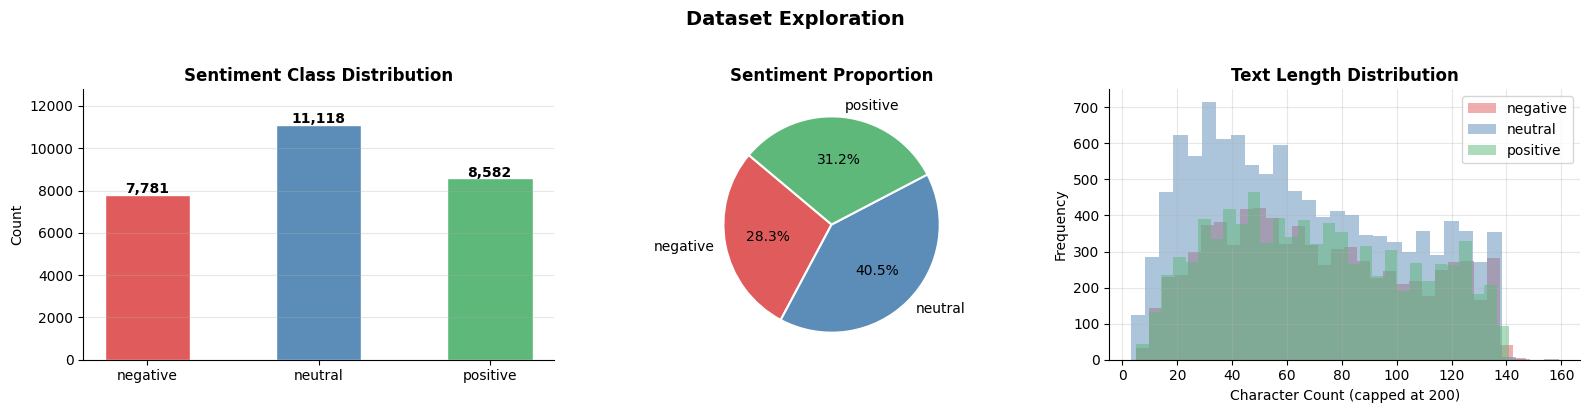


Text length stats:
count    27481.0
mean        68.4
std         35.6
min          3.0
25%         39.0
50%         64.0
75%         97.0
max        159.0
Name: text_len, dtype: float64


In [5]:
LABEL_COL = 'sentiment'
TEXT_COL  = 'text'        # fixed: was incorrectly auto-detected as 'textID'

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
df = df[df[LABEL_COL].isin(['positive', 'neutral', 'negative'])].copy()
df[TEXT_COL]  = df[TEXT_COL].astype(str)

COLORS = {'negative': '#E05C5C', 'neutral': '#5B8DB8', 'positive': '#5DB87A'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Exploration', fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: Class distribution bar ---
counts = df[LABEL_COL].value_counts().reindex(['negative', 'neutral', 'positive'])
bars = axes[0].bar(counts.index, counts.values,
                   color=[COLORS[l] for l in counts.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# --- Plot 2: Pie chart ---
axes[1].pie(counts.values, labels=counts.index,
            colors=[COLORS[l] for l in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Sentiment Proportion', fontweight='bold')

# --- Plot 3: Tweet text length distribution ---
df['text_len'] = df[TEXT_COL].str.len()
for label, grp in df.groupby(LABEL_COL):
    axes[2].hist(grp['text_len'].clip(0, 200), bins=30, alpha=0.5,
                 color=COLORS[label], label=label, edgecolor='none')
axes[2].set_title('Text Length Distribution', fontweight='bold')
axes[2].set_xlabel('Character Count (capped at 200)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nText length stats:\n{df['text_len'].describe().round(1)}")

### Text Preprocessing
Clean tweet text (remove URLs, mentions, hashtags, non-ASCII), encode labels, and sample up to 5000 per class.

In [6]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'#', '', text)               # remove hashtag symbol
    text = re.sub(r'[^\x00-\x7F]', '', text)  # remove non-ASCII
    return text.strip()

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label  = {v: k for k, v in label2id.items()}

df['clean_text'] = df[TEXT_COL].apply(clean_text)
df['label']      = df[LABEL_COL].map(label2id)
df = df.dropna(subset=['clean_text', 'label'])

# Balance: sample up to 5000 per class
df = (df.groupby('label', group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 5000), random_state=SEED))
        .reset_index(drop=True))

print(f"Final dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")

# Show before/after cleaning example
print("\n--- Preprocessing example ---")
idx = 1
print(f"Original : {df[TEXT_COL].iloc[idx]}")
print(f"Cleaned  : {df['clean_text'].iloc[idx]}")

Final dataset shape: (15000, 13)
Label distribution:
label
0    5000
1    5000
2    5000
Name: count, dtype: int64

--- Preprocessing example ---
Original :  that sounds foreboding...
Cleaned  : that sounds foreboding...


### Train / Validation Split
Stratified 80/20 split ensuring equal class representation in both sets.

Train size : 12,000  |  Val size: 3,000
Train label distribution:
label
0    4000
1    4000
2    4000
Name: count, dtype: int64


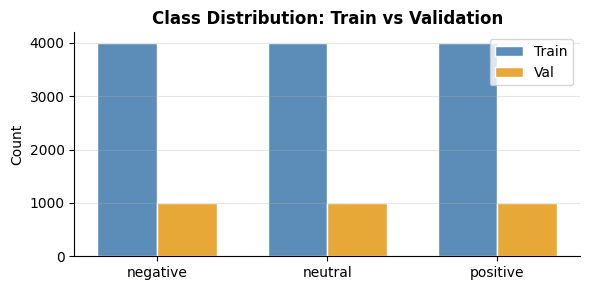

In [7]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size : {len(train_df):,}  |  Val size: {len(val_df):,}")
print(f"Train label distribution:\n{train_df['label'].value_counts().sort_index()}")

# Split distribution comparison bar chart
fig, ax = plt.subplots(figsize=(6, 3))
label_names = ['negative', 'neutral', 'positive']
train_counts = [len(train_df[train_df['label']==i]) for i in range(3)]
val_counts   = [len(val_df[val_df['label']==i])   for i in range(3)]
x = np.arange(3); w = 0.35
b1 = ax.bar(x - w/2, train_counts, w, label='Train', color='#5B8DB8', edgecolor='white')
b2 = ax.bar(x + w/2, val_counts,   w, label='Val',   color='#E8A838', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(label_names)
ax.set_title('Class Distribution: Train vs Validation', fontweight='bold')
ax.set_ylabel('Count'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

### Tokenization & PyTorch Dataset
Load BERT tokenizer, define a custom Dataset class that returns `input_ids`, `attention_mask`, and labels.

In [8]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 32

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(train_df['clean_text'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(val_df['clean_text'],   val_df['label'],   tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64,          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Sample token IDs (first 10): {train_dataset[0]['input_ids'][:10].tolist()}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 375 | Val batches: 47
Sample token IDs (first 10): [101, 9594, 2480, 2194, 2001, 21317, 1012, 1012, 1012, 1045]


### Load Pretrained BERT Model
Load `bert-base-uncased` with a 3-class classification head; `MISSING` warnings for `classifier` weights are expected.

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Total parameters    : 109,484,547
Trainable parameters: 109,484,547


### Training Configuration
Define `AdamW` optimizer (`lr=2e-5`), linear warmup scheduler (10% of steps), and gradient clipping at 1.0.

In [10]:
EPOCHS = 4

optimizer     = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps   = len(train_loader) * EPOCHS
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                        token_type_ids=token_type_ids, labels=labels)
        outputs.loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += outputs.loss.item() * labels.size(0)
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                            token_type_ids=token_type_ids, labels=labels)
            total_loss += outputs.loss.item() * labels.size(0)
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("Training configuration ready.")
print(f"Epochs: {EPOCHS} | Warmup steps: {int(0.1*total_steps)} / {total_steps} total")

Training configuration ready.
Epochs: 4 | Warmup steps: 150 / 1500 total


### Fine-Tune BERT
Train for 4 epochs, saving the best validation accuracy checkpoint; print per-epoch metrics.

In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, device)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_bert_model.pth')
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}{flag}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch 1/4 | Train Loss: 0.7462  Acc: 0.6487 | Val Loss: 0.5636  Acc: 0.7680 ← best
Epoch 2/4 | Train Loss: 0.4538  Acc: 0.8225 | Val Loss: 0.5587  Acc: 0.7900 ← best
Epoch 3/4 | Train Loss: 0.3203  Acc: 0.8823 | Val Loss: 0.6076  Acc: 0.7890
Epoch 4/4 | Train Loss: 0.2306  Acc: 0.9244 | Val Loss: 0.6876  Acc: 0.7857

Best Validation Accuracy: 0.7900


### Training Curves
Plot loss and accuracy over epochs for both train and validation to inspect learning dynamics.

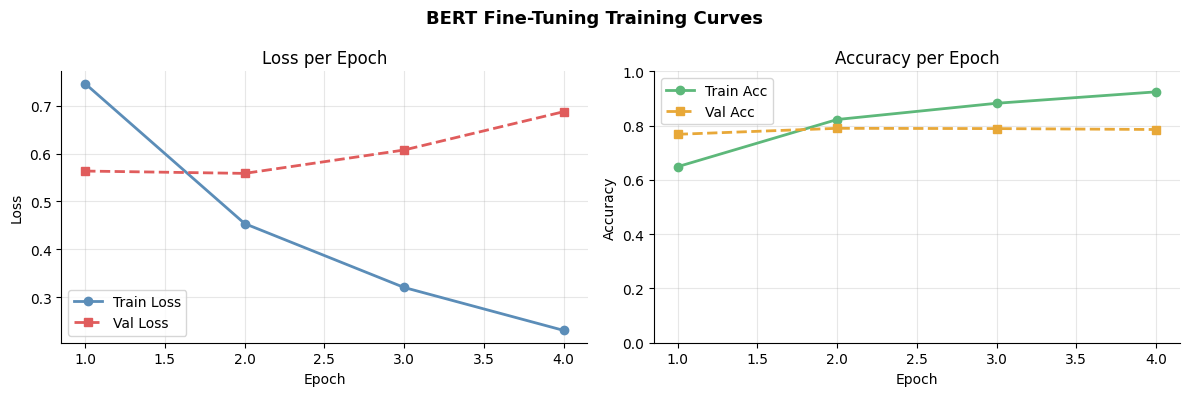

In [12]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('BERT Fine-Tuning Training Curves', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#5B8DB8', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   's--', color='#E05C5C', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].spines[['top','right']].set_visible(False)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', color='#5DB87A', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   's--', color='#E8A838', label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluation — Classification Report
Load the best checkpoint and run inference on the validation set to print precision, recall, and F1 per class.

In [13]:
model.load_state_dict(torch.load('best_bert_model.pth', map_location=device))
_, final_acc, all_preds, all_labels = eval_epoch(model, val_loader, device)

label_names = ['negative', 'neutral', 'positive']
print(f"Final Validation Accuracy: {final_acc:.4f}\n")
print("=" * 55)
print("           Classification Report")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))

Final Validation Accuracy: 0.7900

           Classification Report
              precision    recall  f1-score   support

    negative     0.8478    0.7910    0.8184      1000
     neutral     0.6931    0.7520    0.7213      1000
    positive     0.8422    0.8270    0.8345      1000

    accuracy                         0.7900      3000
   macro avg     0.7943    0.7900    0.7914      3000
weighted avg     0.7943    0.7900    0.7914      3000



### Confusion Matrix
Visualise prediction errors across the three sentiment classes; off-diagonal cells indicate misclassifications.

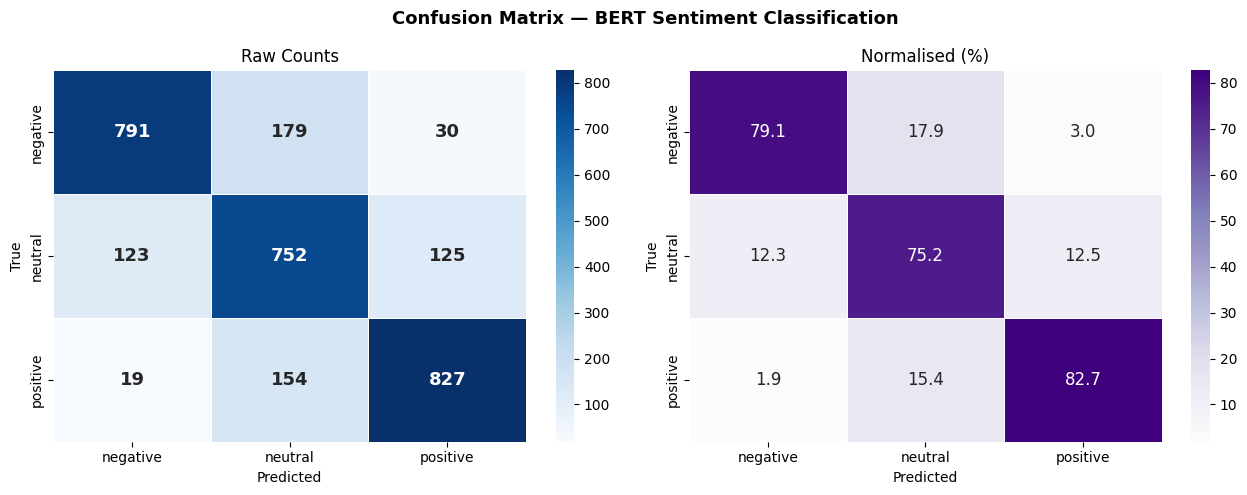

In [14]:
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — BERT Sentiment Classification', fontsize=13, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white', ax=axes[0],
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title('Raw Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Normalised (%)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white', ax=axes[1],
            annot_kws={"size": 12})
axes[1].set_title('Normalised (%)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Custom Sentence Inference
Run the trained model on arbitrary input sentences and display per-class probability scores.

In [15]:
def predict_sentiment(texts, model, tokenizer, device, max_len=128):
    model.eval()
    encoding = tokenizer(texts, max_length=max_len, padding=True,
                         truncation=True, return_tensors='pt')
    with torch.no_grad():
        outputs = model(input_ids=encoding['input_ids'].to(device),
                        attention_mask=encoding['attention_mask'].to(device))
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)
    label_names = ['negative', 'neutral', 'positive']
    results = []
    for text, pred, prob in zip(texts, preds, probs):
        results.append({
            'text': text[:80],
            'prediction': label_names[pred].upper(),
            'confidence': f"{prob[pred]:.3f}",
            'neg': f"{prob[0]:.3f}", 'neu': f"{prob[1]:.3f}", 'pos': f"{prob[2]:.3f}"
        })
    return pd.DataFrame(results)

sample_texts = [
    "I absolutely love this product, it works amazingly well!",
    "The package arrived on time and was as described.",
    "This is the worst experience I have ever had, completely terrible.",
    "Not sure how I feel about this, it's just okay I guess.",
    "Totally exceeded my expectations — would buy again!"
]

results_df = predict_sentiment(sample_texts, model, tokenizer, device)
print("\nSentiment Predictions on Sample Texts:")
print(results_df.to_string(index=False))


Sentiment Predictions on Sample Texts:
                                                              text prediction confidence   neg   neu   pos
          I absolutely love this product, it works amazingly well!   POSITIVE      0.985 0.006 0.009 0.985
                 The package arrived on time and was as described.    NEUTRAL      0.921 0.023 0.921 0.056
This is the worst experience I have ever had, completely terrible.   NEGATIVE      0.988 0.988 0.009 0.003
           Not sure how I feel about this, it's just okay I guess.    NEUTRAL      0.553 0.025 0.553 0.422
               Totally exceeded my expectations — would buy again!    NEUTRAL      0.499 0.397 0.499 0.104
